In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

font_dir = Path("/Users/sophiazhang/anaconda3/envs/shuoz/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf")
font_paths = [
    font_dir / "Myriad Pro Regular.ttf",
    font_dir / "Myriad Pro Bold.ttf",
    font_dir / "MYRIADPRO-SEMIBOLD.OTF"
]

for path in font_paths:
    font_manager.fontManager.addfont(str(path))

plt.rcParams["font.family"] = "Myriad Pro"

fs=16
fss=14

RESULTS_DIR = Path("./results/robustness_DP_ICT")

In [3]:
fp = Path("./results/robustness_digital_input_intensity/robustness_digital_input_intensity_yearly.csv")
out_dir = Path("./results/robustness_digital_input_intensity")
out_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(fp)
df = df.sort_values("year")
df["year"] = df["year"].astype(int)

def interpolate_years(df, year_col="year"):
    df = df.copy()
    df = df.sort_values(year_col)
    df[year_col] = df[year_col].astype(int)
    df = df.set_index(year_col)
    full_years = np.arange(df.index.min(), df.index.max() + 1)
    df = df.reindex(full_years)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].interpolate(method="linear", limit_direction="both")
    df = df.reset_index().rename(columns={"index": year_col})
    return df

df_plot = interpolate_years(df)
years = df_plot["year"].astype(int)

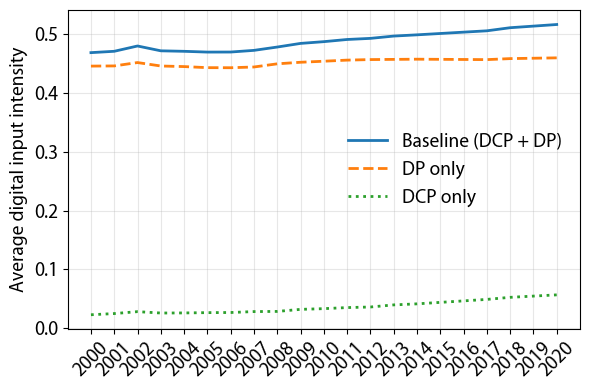

In [9]:
# =========================
# Average digital input intensity under alternative specifications
# =========================
fig, ax = plt.subplots(figsize=(6, 4), facecolor="none")
ax.plot(
    years,
    df_plot["avg_digital_input_intensity_baseline_DCP_DP"],
    linewidth=2,
    label="Baseline (DCP + DP)"
)
ax.plot(
    years,
    df_plot["avg_digital_input_intensity_DP_only"],
    linewidth=2,
    linestyle="--",
    label="DP only"
)
ax.plot(
    years,
    df_plot["avg_digital_input_intensity_DCP_only"],
    linewidth=2,
    linestyle=":",
    label="DCP only"
)

ax.set_ylabel("Average digital input intensity", fontsize=fss)
# ax.set_title("Robustness of average digital input intensity under alternative specifications")
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(labelsize=fss)
ax.legend(fontsize=fss, frameon=False)
ax.grid(alpha=0.3)
ax.set_facecolor('none')
fig.tight_layout()
fig.savefig(out_dir / "average_digital_input_intensity.png", dpi=300)
plt.show()

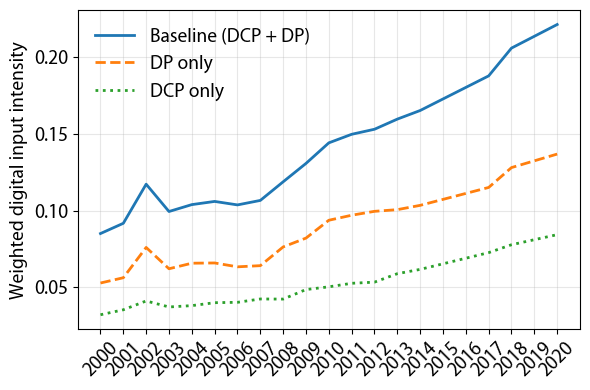

In [10]:
# =========================
# Weighted digital input intensity under alternative specifications
# =========================
fig, ax = plt.subplots(figsize=(6, 4), facecolor="none")
ax.plot(
    years,
    df_plot["weighted_digital_input_intensity_baseline_DCP_DP"],
    linewidth=2,
    label="Baseline (DCP + DP)"
)
ax.plot(
    years,
    df_plot["weighted_digital_input_intensity_DP_only"],
    linewidth=2,
    linestyle="--",
    label="DP only"
)
ax.plot(
    years,
    df_plot["weighted_digital_input_intensity_DCP_only"],
    linewidth=2,
    linestyle=":",
    label="DCP only"
)
ax.set_ylabel("Weighted digital input intensity", fontsize=fss)
# ax.set_title("Robustness of weighted digital input intensity under alternative specifications")
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(labelsize=fss)
ax.legend(fontsize=fss, frameon=False)
ax.grid(alpha=0.3)
ax.set_facecolor('none')
fig.tight_layout()
fig.savefig(out_dir / "weighted_digital_input_intensity.png", dpi=300)
plt.show()

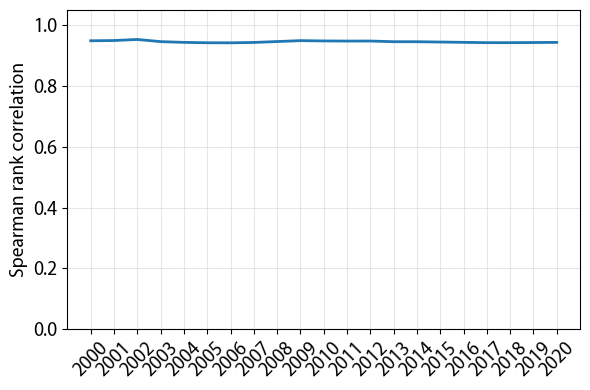

In [11]:
# =========================
# Sectoral ranking stability
# =========================
fig, ax = plt.subplots(figsize=(6, 4), facecolor='none')
ax.plot(
    years,
    df_plot["spearman_rank_corr_baseline_vs_DP_only"],
    linewidth=2
)
ax.set_ylabel("Spearman rank correlation", fontsize=fss)
# ax.set_title("Stability of sectoral rankings under DP-only specification")
ax.set_ylim(0, 1.05)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(labelsize=fss)
ax.grid(alpha=0.3)
ax.set_facecolor('none')
fig.tight_layout()
fig.savefig(out_dir / "rank_correlation.png", dpi=300)
plt.show()